# [BASELINE] PCA SVM Pipeline

In [1]:
# Import necessary packages
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator 

2024-07-14 21:29:53.222339: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def load_images_from_folder(folder, label):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        if img_path.endswith(".jpg"):
            img = Image.open(img_path)  # Load image in original color
            img = img.resize((64, 64))  # Resize to a fixed size
            img_array = np.array(img).flatten()  # Flatten the image
            images.append(img_array)
            labels.append(label)
    return images, labels

In [3]:
# Define paths for the dataset
training_set_inner_path = '/Users/selmaschouw/Documents/Repositories/cbs-mldl-drowsiness-detection/data/CEW_Data_Test_Train/TrainingSet'
test_set_inner_path = '/Users/selmaschouw/Documents/Repositories/cbs-mldl-drowsiness-detection/data/CEW_Data_Test_Train/TestSet'

train_open_path = os.path.join(training_set_inner_path, 'Opened')
train_closed_path = os.path.join(training_set_inner_path, 'Closed')
test_open_path = os.path.join(test_set_inner_path, 'Opened')
test_closed_path = os.path.join(test_set_inner_path, 'Closed')

# Load images and labels for training set
train_open_images, train_open_labels = load_images_from_folder(train_open_path, 1)
train_closed_images, train_closed_labels = load_images_from_folder(train_closed_path, 0)

# Combine training data and labels
X_train = np.array(train_open_images + train_closed_images)
y_train = np.array(train_open_labels + train_closed_labels)

# Load images and labels for test set
test_open_images, test_open_labels = load_images_from_folder(test_open_path, 1)
test_closed_images, test_closed_labels = load_images_from_folder(test_closed_path, 0)

# Combine test data and labels
X_test = np.array(test_open_images + test_closed_images)
y_test = np.array(test_open_labels + test_closed_labels)

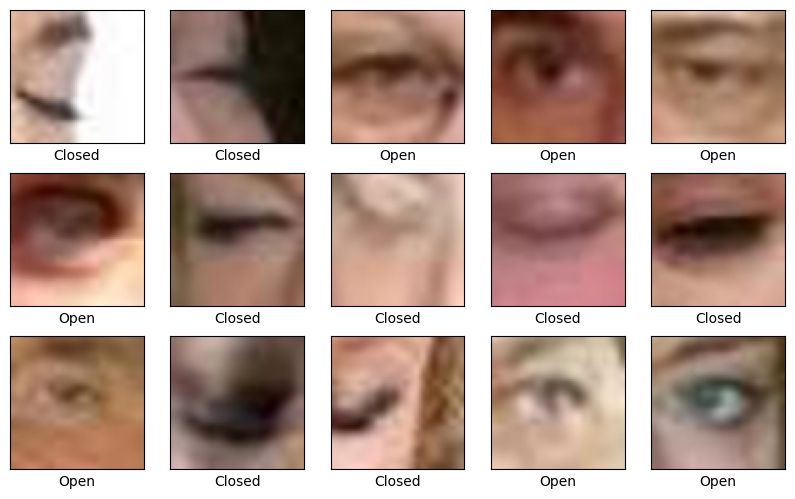

In [4]:
import random
import matplotlib.pyplot as plt

# Randomly shuffle and sample images from both open and closed eye training sets
num_samples = 15  # Total number of images to display (3 rows x 5 columns)
num_open = min(len(train_open_images), num_samples // 2)  # Half from open
num_closed = num_samples - num_open  # Half from closed

sampled_open = random.sample(list(zip(train_open_images, ['Open'] * len(train_open_images))), num_open)
sampled_closed = random.sample(list(zip(train_closed_images, ['Closed'] * len(train_closed_images))), num_closed)
sampled_images = sampled_open + sampled_closed
random.shuffle(sampled_images)

fig, ax = plt.subplots(3, 5, figsize=(10, 6))
for i, axi in enumerate(ax.flat):
    img_array, label = sampled_images[i]
    img = img_array.reshape(64, 64, 3)
    axi.imshow(img)
    axi.set(xticks=[], yticks=[], xlabel=label)
plt.show()


In [5]:
# Apply PCA for dimensionality reduction
pca = PCA(n_components=200, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

'''
# Grid search for hyperparameter tuning
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)
'''
param_grid = {
    'svc__C': [0.5, 1, 1.5, 2],
    'svc__gamma': [0.005, 0.01, 0.02, 0.05]} # Wide range for gamma 
grid = GridSearchCV(model, param_grid, cv=5)  # 5-fold cross-validation

# Fit the model with grid search
grid.fit(X_train, y_train)
print("Best parameters found: ", grid.best_params_)

Best parameters found:  {'svc__C': 2, 'svc__gamma': 0.005}


In [6]:
# Train the SVM classifier with the best parameters
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = best_model.predict(X_test)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Convert classification report to DataFrame for better display
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Display the classification report and confusion matrix
print(report_df)
print(conf_matrix)

              precision    recall  f1-score     support
0              0.898438  0.964361  0.930233  477.000000
1              0.962882  0.894523  0.927445  493.000000
accuracy       0.928866  0.928866  0.928866    0.928866
macro avg      0.930660  0.929442  0.928839  970.000000
weighted avg   0.931191  0.928866  0.928816  970.000000
[[460  17]
 [ 52 441]]


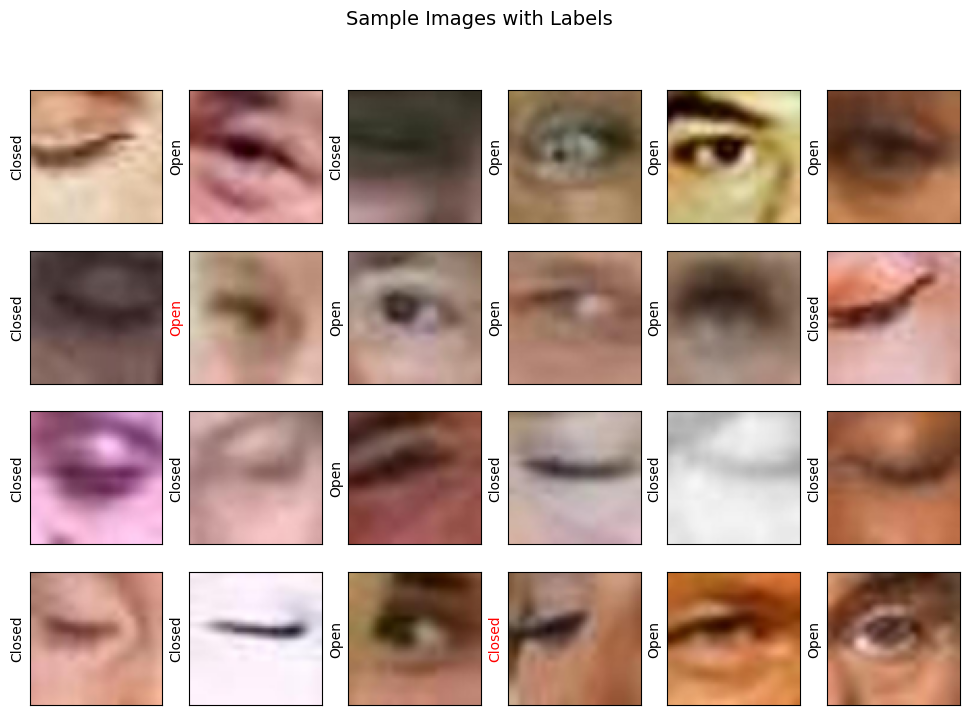

In [7]:
# Generate predictions for the test images
X_test_combined = test_open_images + test_closed_images
y_test_combined = [1] * len(test_open_images) + [0] * len(test_closed_images)
y_pred_combined = best_model.predict(X_test_combined)

# Randomly shuffle and sample images from both open and closed eye test sets
sampled_images_labels = random.sample(list(zip(test_open_images, ['Open'] * len(test_open_images), y_pred_combined[:len(test_open_images)])), 12) + \
                        random.sample(list(zip(test_closed_images, ['Closed'] * len(test_closed_images), y_pred_combined[len(test_open_images):])), 12)
random.shuffle(sampled_images_labels)

fig, ax = plt.subplots(4, 6, figsize=(12, 8))
for i, axi in enumerate(ax.flat):
    img_array, label, pred = sampled_images_labels[i]
    img = img_array.reshape(64, 64, 3)
    correct_label = 'Open' if pred == 1 else 'Closed'
    color = 'black' if label == correct_label else 'red'
    axi.imshow(img)
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(label, color=color)
fig.suptitle('Sample Images with Labels', size=14)
plt.show()

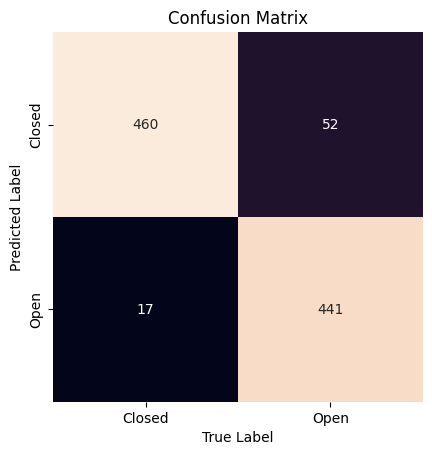

In [8]:
# Display the confusion matrix using a heatmap
mat = confusion_matrix(y_test, y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['Closed', 'Open'],
            yticklabels=['Closed', 'Open'])
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()